# Lecture 6: Convolutional Neural Networks

**Machine Learning Applications in Physics (PHYG004)** | Sogang University, 2026 Spring

---

**Topics:**
1. From Fully-Connected to Convolutional Layers
2. The Convolution Operation
3. Padding and Strides
4. Multiple Channels
5. Pooling Layers
6. Building a CNN with Flax (LeNet-5)
7. Application: Ising Model Phase Classification

**References:**
- [d2l.ai, Ch. 7: CNNs](https://d2l.ai/chapter_convolutional-neural-networks/index.html)
- LeCun et al., *Gradient-Based Learning Applied to Document Recognition*, Proc. IEEE (1998)
- Carrasquilla & Melko, *Machine learning phases of matter*, Nature Physics (2017)

In [45]:
# Setup — run this cell first
# !pip install -q jax jaxlib optax flax matplotlib

import jax
import jax.numpy as jnp
import jax.random as jr
import optax
import flax.nnx as nnx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from functools import partial

# Check device
print(f"JAX backend: {jax.default_backend()}")
print(f"JAX version: {jax.__version__}")

JAX backend: cpu
JAX version: 0.9.2


---
## 1. From Fully-Connected to Convolutional Layers

*Ref: [d2l.ai §7.1](https://d2l.ai/chapter_convolutional-neural-networks/why-conv.html)*

### Why not FC layers for images?

- A $256 \times 256$ grayscale image → FC layer with 256 hidden units needs **~16.8M parameters**
- This ignores two key properties of spatial data:

### Two Principles

- **Translation invariance**: a feature detector should work the same everywhere
  - Physics: Hamiltonian with periodic BC has the same form at every lattice site
- **Locality**: nearby pixels are correlated; distant ones are not
  - Physics: short-range interactions dominate (nearest-neighbor couplings)

### Deriving Convolution from FC

General FC on 2D input: $\quad H_{i,j} = U_{i,j} + \sum_{k,l} W_{i,j,k,l} \, X_{k,l}$

Apply the two constraints:
1. **Translation invariance** → $W_{i,j,k,l} = V_{k-i, \, l-j}$
2. **Locality** → $V_{a,b} = 0$ for $|a| > \Delta$ or $|b| > \Delta$

$$\boxed{H_{i,j} = u + \sum_{a=-\Delta}^{\Delta} \sum_{b=-\Delta}^{\Delta} V_{a,b} \, X_{i+a, \, j+b}}$$

- $\mathbf{V}$ is the **kernel** (filter): only $(2\Delta+1)^2$ parameters, independent of input size

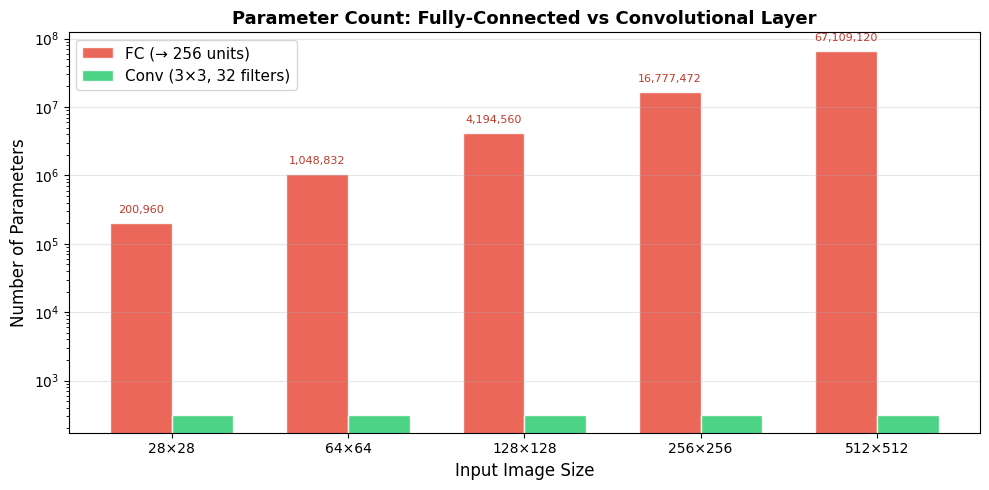


For a 256×256 image:
  FC layer:     16,777,216 parameters
  Conv layer:          288 parameters
  Ratio:            58,254×


In [46]:
# Demonstration: parameter count explosion in fully-connected vs convolutional

image_sizes = [28, 64, 128, 256, 512]
hidden_units = 256
kernel_size = 3
n_filters = 32

fc_params = [size**2 * hidden_units + hidden_units for size in image_sizes]
conv_params = [kernel_size**2 * n_filters + n_filters] * len(image_sizes)  # independent of input size!

fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(image_sizes))
width = 0.35

bars1 = ax.bar(x_pos - width/2, fc_params, width, label=f'FC (→ {hidden_units} units)',
               color='#e74c3c', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x_pos + width/2, conv_params, width, label=f'Conv ({kernel_size}×{kernel_size}, {n_filters} filters)',
               color='#2ecc71', alpha=0.85, edgecolor='white')

ax.set_yscale('log')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'{s}×{s}' for s in image_sizes])
ax.set_xlabel('Input Image Size', fontsize=12)
ax.set_ylabel('Number of Parameters', fontsize=12)
ax.set_title('Parameter Count: Fully-Connected vs Convolutional Layer', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars1, fc_params):
    ax.text(bar.get_x() + bar.get_width()/2, val * 1.3, f'{val:,.0f}',
            ha='center', va='bottom', fontsize=8, color='#c0392b')

plt.tight_layout()
plt.show()

print(f"\nFor a 256×256 image:")
print(f"  FC layer:   {256**2 * hidden_units:>12,} parameters")
print(f"  Conv layer: {kernel_size**2 * n_filters:>12,} parameters")
print(f"  Ratio:      {256**2 * hidden_units / (kernel_size**2 * n_filters):>12,.0f}×")

**What to observe:**

- **Logarithmic scale**: FC parameters grow as $O(n^2)$ with image size while conv parameters stay constant — the gap is already $\sim 10^5\times$ at $256 \times 256$.
- **Why this matters for physics**: Scientific images (detector readouts, simulation snapshots) are often large. A fully-connected approach becomes infeasible, but a convolutional layer remains lightweight.
- **Key insight**: Convolution exploits **translation equivariance** and **locality** — the same kernel is reused everywhere, so parameter count depends only on the kernel size, not the image size.

---
## 2. The Convolution Operation

*Ref: [d2l.ai §7.2](https://d2l.ai/chapter_convolutional-neural-networks/conv-layer.html)*

<img src="https://d2l.ai/_images/correlation.svg" width="400" alt="2D cross-correlation">

*Fig: 2D cross-correlation — kernel slides over input, element-wise multiply and sum. (Source: d2l.ai)*

### Cross-Correlation (what DL calls "convolution")

$$H_{i,j} = \sum_{a=0}^{K_h-1} \sum_{b=0}^{K_w-1} K_{a,b} \cdot X_{i+a, \, j+b} + \text{bias}$$

- True convolution flips the kernel — but since $K$ is learned, the flip is absorbed
- **Physics analogy**: computing a local observable on a lattice — weighted sum over a neighborhood

In [47]:
# Implement 2D cross-correlation from scratch (educational)

def corr2d_naive(X, K):
    """2D cross-correlation with explicit loops (slow, but shows the algorithm)."""
    h, w = K.shape
    H_out = X.shape[0] - h + 1
    W_out = X.shape[1] - w + 1
    Y = jnp.zeros((H_out, W_out))
    for i in range(H_out):
        for j in range(W_out):
            Y = Y.at[i, j].set(jnp.sum(X[i:i+h, j:j+w] * K))
    return Y

def corr2d(X, K):
    """2D cross-correlation using jax.lax.conv (fast)."""
    out = jax.lax.conv(X[None, None], K[None, None], (1, 1), 'VALID')
    return out[0, 0]

# Example: 3×3 input, 2×2 kernel
X = jnp.array([[0., 1., 2.],
                [3., 4., 5.],
                [6., 7., 8.]])

K = jnp.array([[0., 1.],
                [2., 3.]])

result = corr2d(X, K)
print(f"Input X ({X.shape}):")
print(X)
print(f"\nKernel K ({K.shape}):")
print(K)
print(f"\nOutput H ({result.shape}):")
print(result)
print(f"\nManual check H[0,0] = 0×0 + 1×1 + 3×2 + 4×3 = {0*0 + 1*1 + 3*2 + 4*3}")

Input X ((3, 3)):
[[0. 1. 2.]
 [3. 4. 5.]
 [6. 7. 8.]]

Kernel K ((2, 2)):
[[0. 1.]
 [2. 3.]]

Output H ((2, 2)):
[[19. 25.]
 [37. 43.]]

Manual check H[0,0] = 0×0 + 1×1 + 3×2 + 4×3 = 19


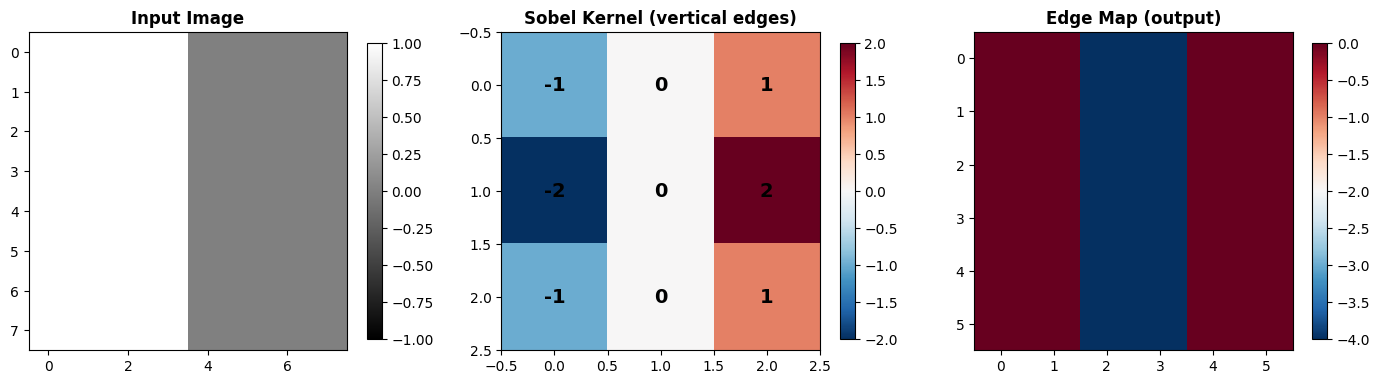

Sobel filter detects the vertical edge. CNNs learn such kernels automatically.


In [48]:
# Application: edge detection with a hand-crafted kernel

# Create a simple image with a vertical edge
image = jnp.zeros((8, 8))
image = image.at[:, :4].set(1.0)  # left half = 1, right half = 0

# Vertical edge detection kernel (detects left-to-right transitions)
K_edge = jnp.array([[-1., 0., 1.],
                     [-2., 0., 2.],
                     [-1., 0., 1.]])  # Sobel filter

edges = corr2d(image, K_edge)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].imshow(image, cmap='gray', vmin=-1, vmax=1)
axes[0].set_title('Input Image', fontsize=12, fontweight='bold')
plt.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(K_edge, cmap='RdBu_r', vmin=-2, vmax=2)
axes[1].set_title('Sobel Kernel (vertical edges)', fontsize=12, fontweight='bold')
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, f'{K_edge[i,j]:.0f}', ha='center', va='center',
                     fontsize=14, fontweight='bold')
plt.colorbar(im1, ax=axes[1], shrink=0.8)

im2 = axes[2].imshow(edges, cmap='RdBu_r')
axes[2].set_title('Edge Map (output)', fontsize=12, fontweight='bold')
plt.colorbar(im2, ax=axes[2], shrink=0.8)

plt.tight_layout()
plt.show()

print("Sobel filter detects the vertical edge. CNNs learn such kernels automatically.")

**What to observe:**

- **Edge map structure**: The output is non-zero only at the boundary between the bright and dark halves — the Sobel kernel responds to *local intensity gradients*.
- **Sign of response**: Positive values (red) indicate a left-to-right bright→dark transition; negative (blue) would indicate the reverse. The kernel's antisymmetric weight pattern ($[-1, 0, +1]$ columns) is what creates this directional sensitivity.
- **Output size**: The edge map is smaller than the input ($6 \times 6$ vs $8 \times 8$) because valid convolution loses $k-1$ pixels per dimension.

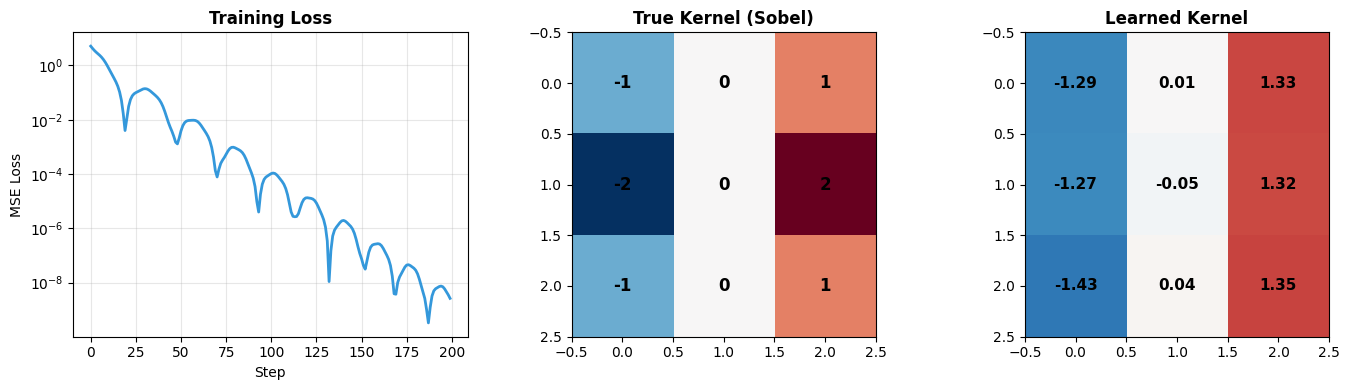

Final loss: 2.62e-09
Learned kernel ≈ Sobel filter — gradient descent discovers edge detection.


In [49]:
# Learning a kernel: can gradient descent recover the Sobel filter?

target = corr2d(image, K_edge)

@jax.jit
def loss_fn(K_flat):
    K = K_flat.reshape(3, 3)
    pred = corr2d(image, K)
    return jnp.mean((pred - target) ** 2)

key = jr.PRNGKey(42)
K_learned = jr.normal(key, (9,)) * 0.1
optimizer = optax.adam(learning_rate=0.1)
opt_state = optimizer.init(K_learned)

losses = []
grad_fn = jax.jit(jax.value_and_grad(loss_fn))
for step in range(200):
    loss, grad = grad_fn(K_learned)
    updates, opt_state = optimizer.update(grad, opt_state)
    K_learned = optax.apply_updates(K_learned, updates)
    losses.append(float(loss))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].semilogy(losses, color='#3498db', linewidth=2)
axes[0].set_xlabel('Step')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training Loss', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

im1 = axes[1].imshow(K_edge, cmap='RdBu_r', vmin=-2, vmax=2)
axes[1].set_title('True Kernel (Sobel)', fontsize=12, fontweight='bold')
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, f'{K_edge[i,j]:.0f}', ha='center', va='center',
                     fontsize=12, fontweight='bold')

K_final = K_learned.reshape(3, 3)
im2 = axes[2].imshow(K_final, cmap='RdBu_r', vmin=-2, vmax=2)
axes[2].set_title('Learned Kernel', fontsize=12, fontweight='bold')
for i in range(3):
    for j in range(3):
        axes[2].text(j, i, f'{K_final[i,j]:.2f}', ha='center', va='center',
                     fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Final loss: {losses[-1]:.2e}")
print(f"Learned kernel ≈ Sobel filter — gradient descent discovers edge detection.")

**What to observe:**

- **Loss curve**: MSE drops rapidly to near zero, showing that gradient descent can recover the correct kernel from a random initialization.
- **Learned vs true kernel**: The learned kernel closely matches the Sobel filter. Small deviations are expected — different kernels can produce the same output on this particular image (the solution is not unique when the training image is simple).
- **Physics analogy**: This is analogous to an *inverse problem* — inferring the operator (kernel) from input-output pairs, just as one might infer a Hamiltonian from observed dynamics.

---
## 3. Padding and Strides

*Ref: [d2l.ai §7.3](https://d2l.ai/chapter_convolutional-neural-networks/padding-and-strides.html)*

<img src="https://d2l.ai/_images/conv-pad.svg" width="400" alt="Padding">

*Fig: Zero-padding preserves spatial dimensions. (Source: d2l.ai)*

<img src="https://d2l.ai/_images/conv-stride.svg" width="400" alt="Stride">

*Fig: Stride > 1 downsamples the feature map. (Source: d2l.ai)*

### Output Size Formula

Input $n_h \times n_w$, kernel $k_h \times k_w$, padding $(p_h, p_w)$, stride $(s_h, s_w)$:

$$\text{output size} = \left\lfloor \frac{n_h - k_h + p_h + s_h}{s_h} \right\rfloor \times \left\lfloor \frac{n_w - k_w + p_w + s_w}{s_w} \right\rfloor$$

| Setting | Padding | Stride | Effect |
|---------|---------|--------|--------|
| **Valid** | 0 | 1 | Output shrinks by $k-1$ |
| **Same** | $k-1$ | 1 | Output = Input size |
| **Downsample** | varies | 2 | Output $\approx$ Input/2 |

- Without padding, after $L$ layers: $n_{\text{out}} = n_{\text{in}} - L(k-1)$
- 28×28 input + 3×3 kernels → only 13 layers before feature map vanishes

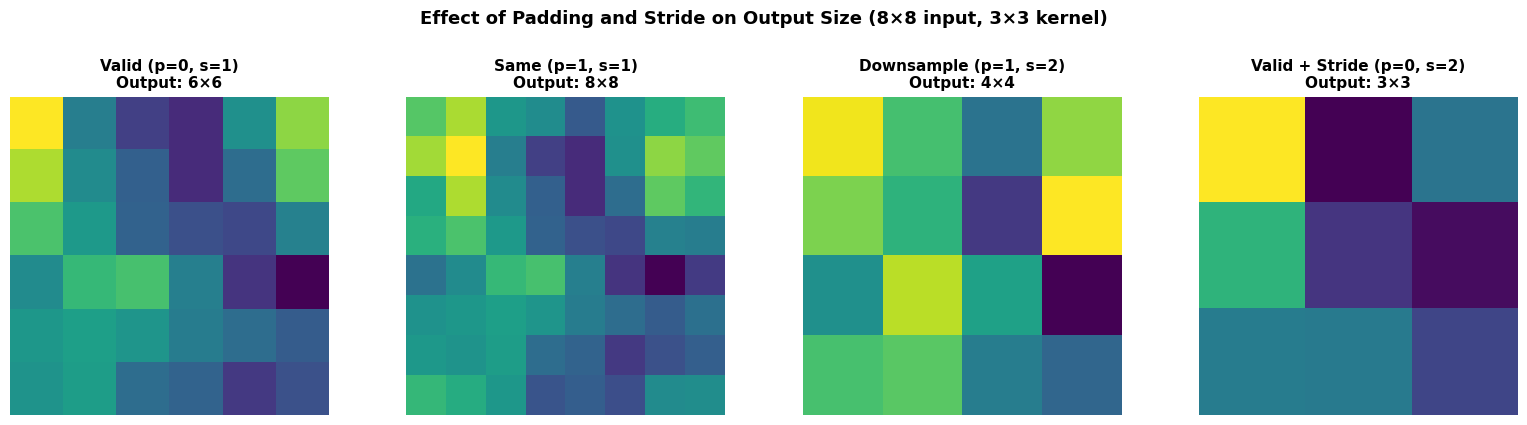

In [50]:
# Convolution with padding and stride using JAX

def conv2d_general(X, K, padding=0, stride=1):
    """2D convolution with padding and stride via jax.lax.conv_general_dilated."""
    if padding > 0:
        X = jnp.pad(X, ((padding, padding), (padding, padding)))
    return jax.lax.conv_general_dilated(
        X[None, None], K[None, None],
        window_strides=(stride, stride), padding='VALID'
    )[0, 0]

# Demonstrate different padding/stride combinations
key = jr.PRNGKey(0)
X = jr.normal(key, (8, 8))
K = jnp.ones((3, 3)) / 9  # averaging kernel

configs = [
    (0, 1, 'Valid (p=0, s=1)'),
    (1, 1, 'Same (p=1, s=1)'),
    (1, 2, 'Downsample (p=1, s=2)'),
    (0, 2, 'Valid + Stride (p=0, s=2)'),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (p, s, title) in zip(axes, configs):
    out = conv2d_general(X, K, padding=p, stride=s)
    ax.imshow(out, cmap='viridis')
    ax.set_title(f'{title}\nOutput: {out.shape[0]}×{out.shape[1]}', fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle('Effect of Padding and Stride on Output Size (8×8 input, 3×3 kernel)',
             fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

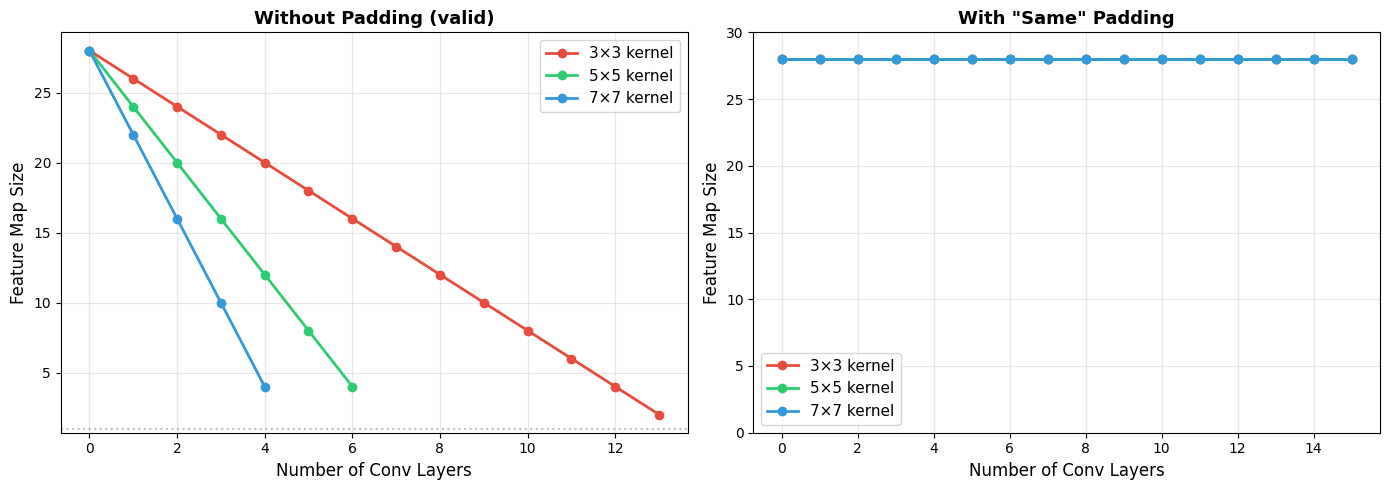

In [51]:
# Visualize how feature map size shrinks without padding

kernel_sizes = [3, 5, 7]
n_in = 28
max_layers = 15

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e74c3c', '#2ecc71', '#3498db']

# Without padding
for k, color in zip(kernel_sizes, colors):
    sizes = [n_in]
    for L in range(1, max_layers + 1):
        new_size = sizes[-1] - (k - 1)
        if new_size <= 0:
            break
        sizes.append(new_size)
    axes[0].plot(range(len(sizes)), sizes, 'o-', color=color, linewidth=2,
                 markersize=6, label=f'{k}×{k} kernel')

axes[0].set_xlabel('Number of Conv Layers', fontsize=12)
axes[0].set_ylabel('Feature Map Size', fontsize=12)
axes[0].set_title('Without Padding (valid)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)
axes[0].axhline(y=1, color='gray', linestyle=':', alpha=0.5)

# With same padding
for k, color in zip(kernel_sizes, colors):
    sizes = [n_in] * (max_layers + 1)
    axes[1].plot(range(len(sizes)), sizes, 'o-', color=color, linewidth=2,
                 markersize=6, label=f'{k}×{k} kernel')

axes[1].set_xlabel('Number of Conv Layers', fontsize=12)
axes[1].set_ylabel('Feature Map Size', fontsize=12)
axes[1].set_title('With "Same" Padding', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 30)

plt.tight_layout()
plt.show()

**What to observe:**

- **Without padding** (left): Feature maps shrink by $k-1$ pixels per layer. Larger kernels ($7 \times 7$) exhaust the spatial dimensions in just a few layers — the representation collapses to a single pixel.
- **With "same" padding** (right): Feature map size remains constant regardless of kernel size or depth, enabling very deep networks.
- **Design trade-off**: Valid convolution is simpler and avoids boundary artifacts, but same padding is essential when you need to preserve spatial resolution (e.g., segmentation tasks, pixel-level predictions in physics simulations).

---
## 4. Multiple Input and Output Channels

*Ref: [d2l.ai §7.4](https://d2l.ai/chapter_convolutional-neural-networks/channels.html)*

<img src="https://d2l.ai/_images/conv-multi-in.svg" width="400" alt="Multi-input channel convolution">

*Fig: With multiple input channels, apply one kernel per channel and sum. (Source: d2l.ai)*

### Multiple Input Channels

- RGB image → 3 channels; spin system → multiple order parameters per site
- Kernel shape: $C_{\text{in}} \times K_h \times K_w$; outputs from each channel are **summed**:

$$H_{i,j} = \sum_{c=0}^{C_{\text{in}}-1} \sum_{a,b} K_{c,a,b} \cdot X_{c, i+a, j+b} + \text{bias}$$

### Multiple Output Channels

- Each output channel = different feature detector (edges, textures, corners, ...)
- Full kernel tensor: $\mathbf{K} \in \mathbb{R}^{C_{\text{out}} \times C_{\text{in}} \times K_h \times K_w}$

### 1×1 Convolutions

<img src="https://d2l.ai/_images/conv-1x1.svg" width="350" alt="1x1 convolution">

- No spatial neighbors — only mixes channels
- Equivalent to FC layer applied independently at each spatial position

In [52]:
# Multi-channel convolution using jax.lax.conv

def corr2d_multi_in_out(X, K):
    """Multi-channel convolution. X: (C_in, H, W), K: (C_out, C_in, K_h, K_w)."""
    # lax.conv expects (batch, C_in, H, W) and (C_out, C_in, Kh, Kw)
    return jax.lax.conv(X[None], K, (1, 1), 'VALID')[0]

# Example: 2-channel input, 3 output channels
key = jr.PRNGKey(42)
k1, k2 = jr.split(key)

X_mc = jr.normal(k1, (2, 5, 5))         # 2 input channels, 5×5
K_mc = jr.normal(k2, (3, 2, 3, 3))      # 3 output channels, 2 input channels, 3×3

out = corr2d_multi_in_out(X_mc, K_mc)
print(f"Input shape:  (C_in, H, W) = {X_mc.shape}")
print(f"Kernel shape: (C_out, C_in, K_h, K_w) = {K_mc.shape}")
print(f"Output shape: (C_out, H_out, W_out) = {out.shape}")
print(f"\nTotal kernel parameters: {K_mc.size} = C_out × C_in × K_h × K_w = {3}×{2}×{3}×{3}")

Input shape:  (C_in, H, W) = (2, 5, 5)
Kernel shape: (C_out, C_in, K_h, K_w) = (3, 2, 3, 3)
Output shape: (C_out, H_out, W_out) = (3, 3, 3)

Total kernel parameters: 54 = C_out × C_in × K_h × K_w = 3×2×3×3


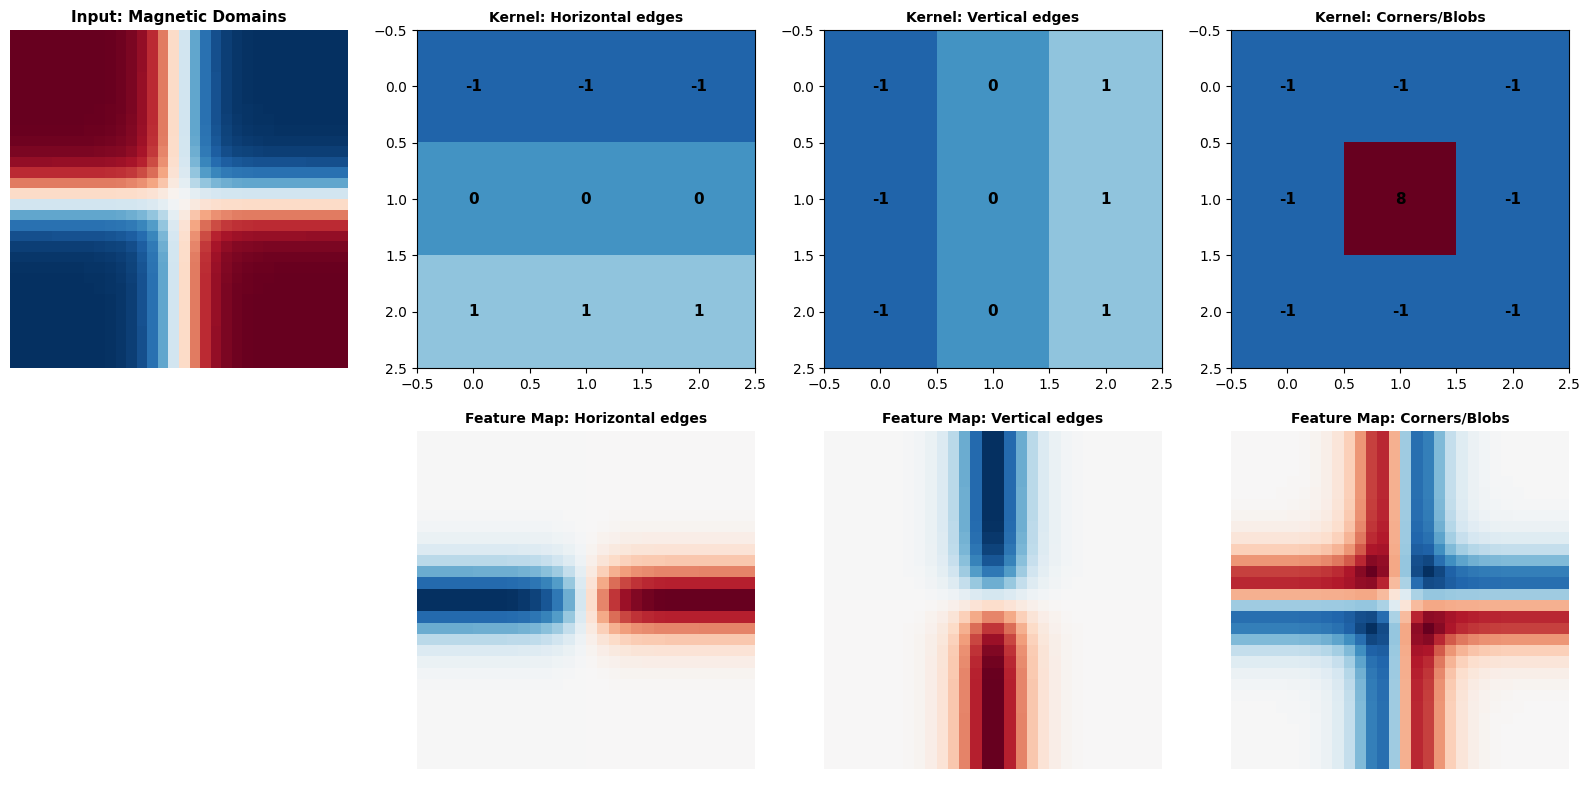

Different kernels → different features. In a CNN, these are LEARNED.


In [53]:
# Visualize what multiple output channels detect
# Use common edge-detection kernels on a synthetic physics-like image

# Create a simple "domain wall" image (like magnetic domains)
x = jnp.linspace(-3, 3, 32)
y = jnp.linspace(-3, 3, 32)
xx, yy = jnp.meshgrid(x, y)
domain_image = jnp.tanh(2*xx) * jnp.tanh(2*yy)  # four-domain pattern

# Different feature detectors
kernels = {
    'Horizontal edges': jnp.array([[-1., -1., -1.],
                                    [ 0.,  0.,  0.],
                                    [ 1.,  1.,  1.]]),
    'Vertical edges':   jnp.array([[-1., 0., 1.],
                                    [-1., 0., 1.],
                                    [-1., 0., 1.]]),
    'Corners/Blobs':    jnp.array([[-1., -1., -1.],
                                    [-1.,  8., -1.],
                                    [-1., -1., -1.]]),
}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Top row: input and kernels
axes[0, 0].imshow(domain_image, cmap='RdBu_r', vmin=-1, vmax=1)
axes[0, 0].set_title('Input: Magnetic Domains', fontsize=11, fontweight='bold')
axes[0, 0].axis('off')

for i, (name, K) in enumerate(kernels.items()):
    im = axes[0, i+1].imshow(K, cmap='RdBu_r', vmin=-2, vmax=8)
    axes[0, i+1].set_title(f'Kernel: {name}', fontsize=10, fontweight='bold')
    for a in range(3):
        for b in range(3):
            axes[0, i+1].text(b, a, f'{K[a,b]:.0f}', ha='center', va='center',
                             fontsize=11, fontweight='bold')

# Bottom row: feature maps
axes[1, 0].axis('off')  # empty
for i, (name, K) in enumerate(kernels.items()):
    feature_map = corr2d(domain_image, K)
    im = axes[1, i+1].imshow(feature_map, cmap='RdBu_r')
    axes[1, i+1].set_title(f'Feature Map: {name}', fontsize=10, fontweight='bold')
    axes[1, i+1].axis('off')

plt.tight_layout()
plt.show()

print("Different kernels → different features. In a CNN, these are LEARNED.")

**What to observe:**

- **Different kernels, different features**: The horizontal-edge kernel highlights the horizontal domain walls, the vertical-edge kernel highlights vertical walls, and the Laplacian-like kernel highlights corners where four domains meet.
- **Physics connection**: The input mimics a magnetic domain structure ($\tanh$ profiles ≈ domain walls in Ginzburg–Landau theory). Each kernel extracts a different *order-parameter gradient* — convolution is performing local differential operations.
- **Multiple output channels**: In a CNN, each output channel acts as a separate learned feature detector. The network discovers which local patterns are most useful for the task at hand.

---
## 5. Pooling Layers

*Ref: [d2l.ai §7.5](https://d2l.ai/chapter_convolutional-neural-networks/pooling.html)*

<img src="https://d2l.ai/_images/pooling.svg" width="400" alt="Max pooling operation">

*Fig: 2×2 max pooling — take the maximum in each window. (Source: d2l.ai)*

### Why Pooling?

- Convolution is **equivariant** (shift input → shift output)
- Classification needs **invariance** (label shouldn't change with small shifts)
- Pooling aggregates over local neighborhoods:
  - **Approximate translation invariance**
  - **Dimensionality reduction** → fewer parameters downstream

### Physics Analogy

- Pooling $\approx$ **coarse-graining** in the renormalization group
- Replace a block of lattice sites with a single effective variable

### Max vs Average Pooling

- **Max**: $\text{Pool}_{i,j} = \max_{(a,b) \in \text{window}} X_{i+a, j+b}$ — "is this feature present?"
- **Average**: $\text{Pool}_{i,j} = \frac{1}{|\text{window}|} \sum X_{i+a, j+b}$ — smooth downsampling (block averaging in RG)

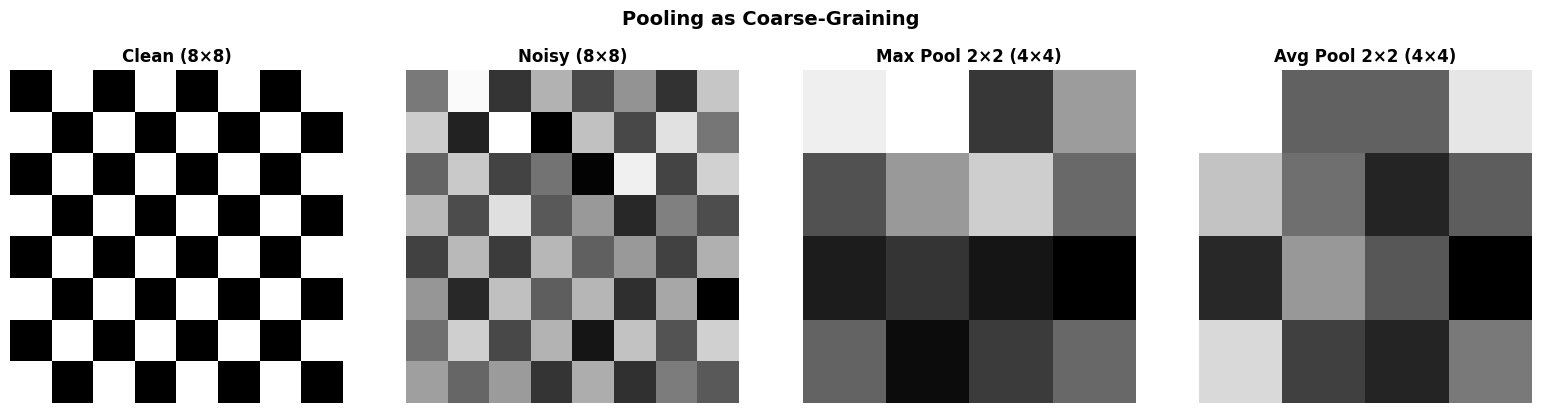

Max pool → strongest signal; avg pool → smooth downsampling (block-spin RG).


In [54]:
# Implement max and average pooling from scratch

def max_pool2d(X, pool_size=2, stride=2):
    """2×2 max pooling with stride 2."""
    H_out = (X.shape[0] - pool_size) // stride + 1
    W_out = (X.shape[1] - pool_size) // stride + 1
    Y = jnp.zeros((H_out, W_out))
    for i in range(H_out):
        for j in range(W_out):
            window = X[i*stride:i*stride+pool_size, j*stride:j*stride+pool_size]
            Y = Y.at[i, j].set(jnp.max(window))
    return Y

def avg_pool2d(X, pool_size=2, stride=2):
    """2×2 average pooling with stride 2."""
    H_out = (X.shape[0] - pool_size) // stride + 1
    W_out = (X.shape[1] - pool_size) // stride + 1
    Y = jnp.zeros((H_out, W_out))
    for i in range(H_out):
        for j in range(W_out):
            window = X[i*stride:i*stride+pool_size, j*stride:j*stride+pool_size]
            Y = Y.at[i, j].set(jnp.mean(window))
    return Y

# Demonstrate on a checkerboard pattern
check = jnp.zeros((8, 8))
for i in range(8):
    for j in range(8):
        check = check.at[i, j].set(float((i + j) % 2))

# Add some noise
key = jr.PRNGKey(0)
noisy = check + 0.3 * jr.normal(key, (8, 8))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(check, cmap='gray')
axes[0].set_title('Clean (8×8)', fontsize=12, fontweight='bold')

axes[1].imshow(noisy, cmap='gray')
axes[1].set_title('Noisy (8×8)', fontsize=12, fontweight='bold')

axes[2].imshow(max_pool2d(noisy), cmap='gray')
axes[2].set_title('Max Pool 2×2 (4×4)', fontsize=12, fontweight='bold')

axes[3].imshow(avg_pool2d(noisy), cmap='gray')
axes[3].set_title('Avg Pool 2×2 (4×4)', fontsize=12, fontweight='bold')

for ax in axes:
    ax.axis('off')

plt.suptitle('Pooling as Coarse-Graining', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Max pool → strongest signal; avg pool → smooth downsampling (block-spin RG).")

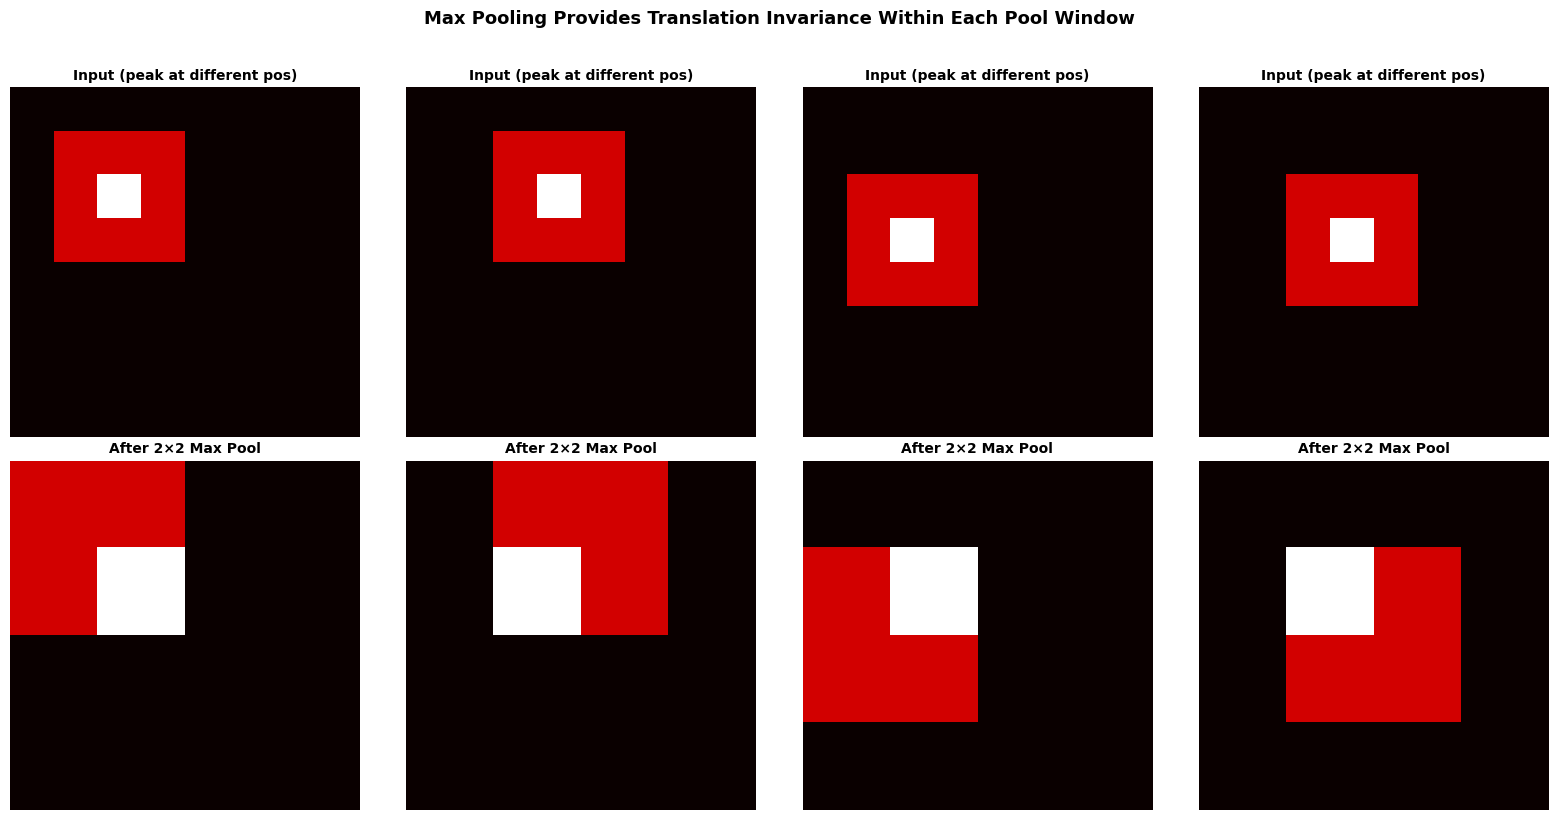

All shifted inputs → same pooled output. Position within the window doesn't matter.


In [55]:
# Demonstrate translation invariance from pooling

# Create a small feature with a "peak" at different positions
def make_peaked_image(peak_i, peak_j, size=8):
    img = jnp.zeros((size, size))
    img = img.at[peak_i, peak_j].set(1.0)
    img = img.at[max(0, peak_i-1):peak_i+2, max(0, peak_j-1):peak_j+2].set(0.3)
    img = img.at[peak_i, peak_j].set(1.0)
    return img

# Peak at different positions (but within the same 2×2 pool region)
imgs = [make_peaked_image(2, 2), make_peaked_image(2, 3),
        make_peaked_image(3, 2), make_peaked_image(3, 3)]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, img in enumerate(imgs):
    axes[0, i].imshow(img, cmap='hot', vmin=0, vmax=1)
    axes[0, i].set_title(f'Input (peak at different pos)', fontsize=10, fontweight='bold')
    axes[0, i].grid(True, color='white', alpha=0.3)

    pooled = max_pool2d(img)
    axes[1, i].imshow(pooled, cmap='hot', vmin=0, vmax=1)
    axes[1, i].set_title(f'After 2×2 Max Pool', fontsize=10, fontweight='bold')

for ax in axes.flat:
    ax.axis('off')

axes[0, 0].set_ylabel('Input', fontsize=12)
axes[1, 0].set_ylabel('Pooled', fontsize=12)

plt.suptitle('Max Pooling Provides Translation Invariance Within Each Pool Window',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("All shifted inputs → same pooled output. Position within the window doesn't matter.")

**What to observe:**

- **Same output from shifted inputs**: All four inputs place the peak at different positions within the same $2 \times 2$ pooling window, yet the max-pooled outputs are identical. This is **translation invariance** within the window.
- **Information trade-off**: Pooling discards *where exactly* the feature is (fine-grained position) but retains *whether* it is present — a useful inductive bias when exact position is less important than existence.
- **Resolution reduction**: The $8 \times 8$ input becomes $4 \times 4$ after pooling, halving each spatial dimension. This progressive downsampling is how CNNs build up large receptive fields while keeping computation manageable.

---
## 6. Building a CNN with Flax: LeNet-5

*Ref: [d2l.ai §7.6](https://d2l.ai/chapter_convolutional-neural-networks/lenet.html) | [LeCun et al., 1998](http://yann.lecun.com/exdb/publis/pdf/lecun-98.pdf)*

<img src="https://d2l.ai/_images/lenet.svg" width="700" alt="LeNet-5 architecture">

*Fig: LeNet-5 architecture — conv/pool blocks extract features, FC layers classify. (Source: d2l.ai)*

### Key Ideas

- First widely successful CNN (handwritten digit recognition, AT&T Bell Labs)
- **Pattern**: Conv+ReLU → Pool → Conv+ReLU → Pool → Flatten → FC → FC → Output
- Each conv+pool block extracts increasingly abstract features:
  - Layer 1: edges, gradients (local)
  - Layer 2: corners, textures (combinations of edges)
  - FC layers: global patterns

### Architecture

```
Input (1×28×28)
  → Conv(6, 5×5, same) + ReLU  → (6×28×28)
  → MaxPool(2×2, stride 2)      → (6×14×14)
  → Conv(16, 5×5, valid) + ReLU → (16×10×10)
  → MaxPool(2×2, stride 2)      → (16×5×5)
  → Flatten → Dense(120) → Dense(84) → Dense(10)
```

In [56]:
# Define LeNet-5 using Flax NNX

class LeNet(nnx.Module):
    def __init__(self, num_classes: int = 10, *, rngs: nnx.Rngs):
        self.conv1 = nnx.Conv(in_features=1, out_features=6, kernel_size=(5, 5),
                              padding='SAME', rngs=rngs)
        self.conv2 = nnx.Conv(in_features=6, out_features=16, kernel_size=(5, 5),
                              padding='VALID', rngs=rngs)
        self.fc1 = nnx.Linear(in_features=16 * 5 * 5, out_features=120, rngs=rngs)
        self.fc2 = nnx.Linear(in_features=120, out_features=84, rngs=rngs)
        self.fc3 = nnx.Linear(in_features=84, out_features=num_classes, rngs=rngs)

    def __call__(self, x):
        # x: (batch, 28, 28, 1)
        x = nnx.relu(self.conv1(x))                       # (batch, 28, 28, 6)
        x = nnx.max_pool(x, (2, 2), strides=(2, 2))      # (batch, 14, 14, 6)
        x = nnx.relu(self.conv2(x))                       # (batch, 10, 10, 16)
        x = nnx.max_pool(x, (2, 2), strides=(2, 2))      # (batch, 5, 5, 16)
        x = x.reshape(x.shape[0], -1)                     # (batch, 400)
        x = nnx.relu(self.fc1(x))                         # (batch, 120)
        x = nnx.relu(self.fc2(x))                         # (batch, 84)
        x = self.fc3(x)                                   # (batch, 10)
        return x

# Instantiate and test
model = LeNet(rngs=nnx.Rngs(0))
dummy = jnp.zeros((1, 28, 28, 1))
out = model(dummy)
print(f"Input shape:  {dummy.shape}")
print(f"Output shape: {out.shape}")

# Count parameters
params = nnx.state(model, nnx.Param)
total_params = sum(p.size for p in jax.tree.leaves(params))
print(f"Total parameters: {total_params:,}")
print(f"\nFC equivalent (first layer alone): 28×28×120 + 120 = {28*28*120 + 120:,} params")

Input shape:  (1, 28, 28, 1)
Output shape: (1, 10)
Total parameters: 61,706

FC equivalent (first layer alone): 28×28×120 + 120 = 94,200 params


---
## 7. Application: Classifying Ising Model Phases

*Refs: [Carrasquilla & Melko, Nat. Phys. 13, 431 (2017)](https://doi.org/10.1038/nphys4035) | [Mehta et al., Phys. Rep. 810, 1 (2019)](https://doi.org/10.1016/j.physrep.2019.03.001)*

### The Physics

- 2D Ising model: $H = -J \sum_{\langle i,j \rangle} s_i s_j, \quad s_i \in \{+1, -1\}$
- Phase transition at $T_c \approx 2.269 \, J/k_B$ (Onsager, 1944):
  - $T < T_c$: ordered (ferromagnetic), $|m| \approx 1$
  - $T > T_c$: disordered (paramagnetic), $|m| \approx 0$

### The ML Task

- **Input**: spin configuration ($L \times L$ grid of $\pm 1$)
- **Output**: ordered vs disordered phase

### Why CNNs fit this problem

- Spin configs = 2D images (pixel = spin)
- Phase depends on **local correlations** (nearest-neighbor alignment)
- **Translation invariant**: phase is the same everywhere on the lattice
- CNN should learn features $\sim$ correlation function $\langle s_i s_j \rangle$

In [57]:
# Generate 2D Ising configurations using Metropolis Monte Carlo
# Uses checkerboard decomposition for vectorized updates + JIT compilation

def nn_sum(spins):
    """Sum of 4 nearest neighbors with periodic BC (vectorized via jnp.roll)."""
    return (jnp.roll(spins, 1, axis=0) + jnp.roll(spins, -1, axis=0) +
            jnp.roll(spins, 1, axis=1) + jnp.roll(spins, -1, axis=1))

@jax.jit
def checkerboard_sweep(key, spins, beta, even_mask, odd_mask):
    """One Metropolis sweep: update even sublattice, then odd (no conflicts)."""
    k1, k2 = jr.split(key)
    L = spins.shape[0]

    # Even sublattice
    neighbors = nn_sum(spins)
    dE = 2.0 * spins * neighbors
    accept = (dE < 0) | (jr.uniform(k1, (L, L)) < jnp.exp(-beta * dE))
    spins = jnp.where(accept & even_mask, -spins, spins)

    # Odd sublattice
    neighbors = nn_sum(spins)
    dE = 2.0 * spins * neighbors
    accept = (dE < 0) | (jr.uniform(k2, (L, L)) < jnp.exp(-beta * dE))
    spins = jnp.where(accept & odd_mask, -spins, spins)

    return spins

def make_checkerboard_masks(L):
    i, j = jnp.meshgrid(jnp.arange(L), jnp.arange(L), indexing='ij')
    even = (i + j) % 2 == 0
    odd = ~even
    return even, odd

def generate_ising_configs(key, L, T, n_equilib=300, n_sample=10, decorr=5):
    """Generate equilibrated Ising configurations at temperature T."""
    beta = 1.0 / T
    even_mask, odd_mask = make_checkerboard_masks(L)
    k1, k2 = jr.split(key)
    spins = 2 * jr.bernoulli(k1, shape=(L, L)).astype(jnp.float32) - 1

    for _ in range(n_equilib):
        k2, subkey = jr.split(k2)
        spins = checkerboard_sweep(subkey, spins, beta, even_mask, odd_mask)

    configs = []
    for step in range(n_sample * decorr):
        k2, subkey = jr.split(k2)
        spins = checkerboard_sweep(subkey, spins, beta, even_mask, odd_mask)
        if step % decorr == 0:
            configs.append(spins.copy())
    return jnp.stack(configs)

print("Ising MC sampler defined (checkerboard decomposition + JIT).")

Ising MC sampler defined (checkerboard decomposition + JIT).


In [58]:
# Generate dataset: ordered (T < Tc) and disordered (T > Tc)
# Tc ≈ 2.269 for the 2D Ising model

L = 16
Tc = 2.269

T_low = [1.0, 1.5, 1.8, 2.0]    # ordered phase
T_high = [2.5, 2.8, 3.0, 3.5]   # disordered phase

key = jr.PRNGKey(42)
configs_ordered, configs_disordered = [], []

print("Generating Ising configurations (this may take a minute)...")
for T in T_low:
    key, subkey = jr.split(key)
    cfgs = generate_ising_configs(subkey, L, T, n_equilib=300, n_sample=10, decorr=5)
    configs_ordered.append(cfgs)
    mag = jnp.mean(jnp.abs(jnp.mean(cfgs, axis=(1, 2))))
    print(f"  T={T:.1f} (T/Tc={T/Tc:.2f}): {len(cfgs)} configs, <|m|>={mag:.3f}")

for T in T_high:
    key, subkey = jr.split(key)
    cfgs = generate_ising_configs(subkey, L, T, n_equilib=300, n_sample=10, decorr=5)
    configs_disordered.append(cfgs)
    mag = jnp.mean(jnp.abs(jnp.mean(cfgs, axis=(1, 2))))
    print(f"  T={T:.1f} (T/Tc={T/Tc:.2f}): {len(cfgs)} configs, <|m|>={mag:.3f}")

X_ordered = jnp.concatenate(configs_ordered)
X_disordered = jnp.concatenate(configs_disordered)
print(f"\nDataset: {len(X_ordered)} ordered + {len(X_disordered)} disordered = {len(X_ordered)+len(X_disordered)} total")

Generating Ising configurations (this may take a minute)...
  T=1.0 (T/Tc=0.44): 10 configs, <|m|>=0.998
  T=1.5 (T/Tc=0.66): 10 configs, <|m|>=0.988
  T=1.8 (T/Tc=0.79): 10 configs, <|m|>=0.958
  T=2.0 (T/Tc=0.88): 10 configs, <|m|>=0.904
  T=2.5 (T/Tc=1.10): 10 configs, <|m|>=0.459
  T=2.8 (T/Tc=1.23): 10 configs, <|m|>=0.202
  T=3.0 (T/Tc=1.32): 10 configs, <|m|>=0.119
  T=3.5 (T/Tc=1.54): 10 configs, <|m|>=0.095

Dataset: 40 ordered + 40 disordered = 80 total


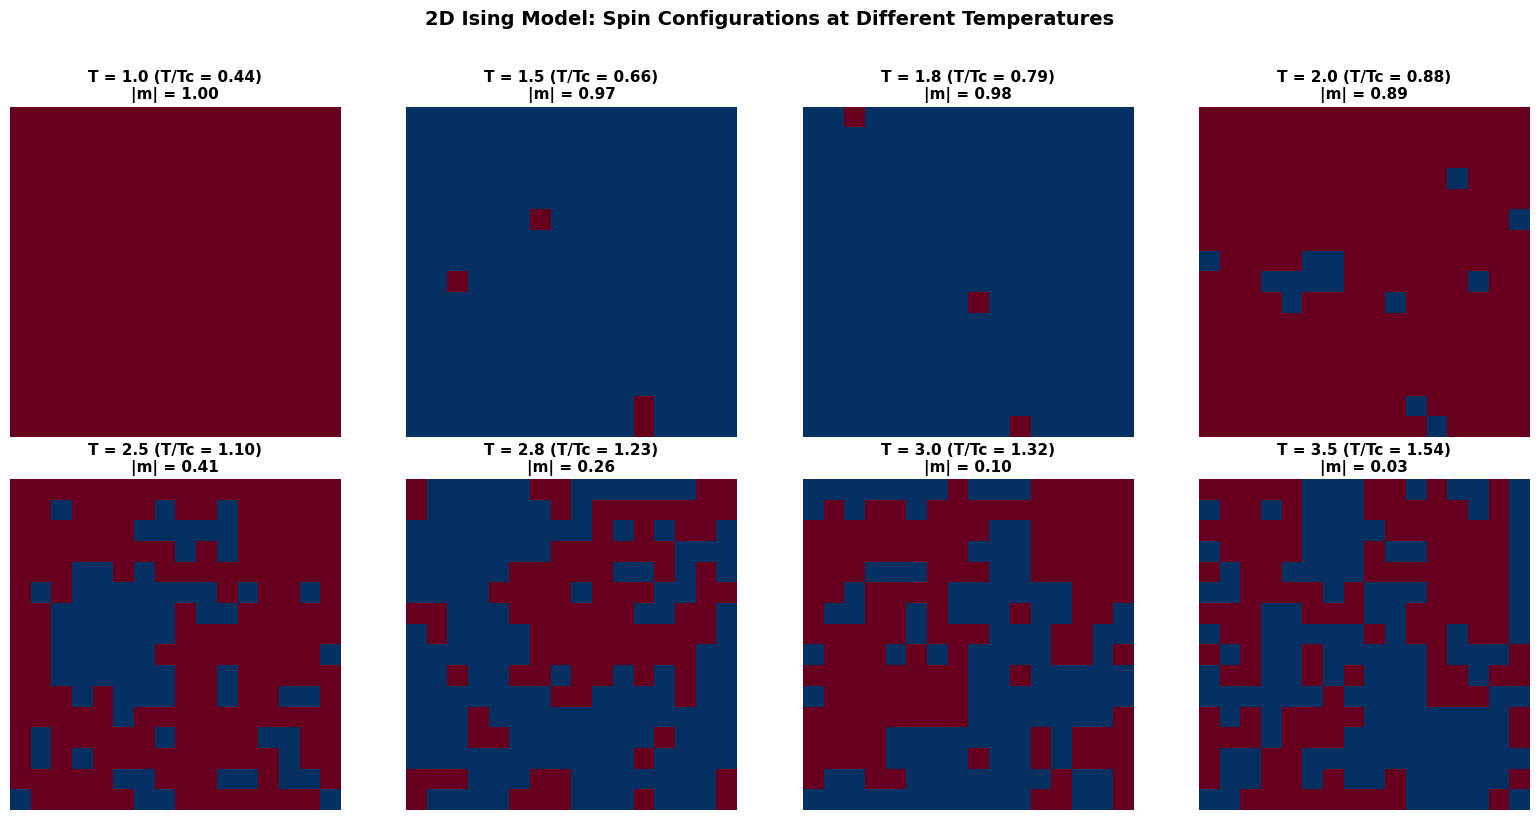

Red=+1, Blue=−1 | Below Tc≈2.269: ordered domains | Above Tc: disordered


In [59]:
# Visualize sample configurations from each phase

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, T in enumerate(T_low):
    idx = i * 10  # pick from different temperatures
    axes[0, i].imshow(X_ordered[idx], cmap='RdBu_r', vmin=-1, vmax=1, interpolation='nearest')
    mag = jnp.abs(jnp.mean(X_ordered[idx]))
    axes[0, i].set_title(f'T = {T:.1f} (T/Tc = {T/Tc:.2f})\n|m| = {mag:.2f}',
                         fontsize=11, fontweight='bold')
    axes[0, i].axis('off')

for i, T in enumerate(T_high):
    idx = i * 10
    axes[1, i].imshow(X_disordered[idx], cmap='RdBu_r', vmin=-1, vmax=1, interpolation='nearest')
    mag = jnp.abs(jnp.mean(X_disordered[idx]))
    axes[1, i].set_title(f'T = {T:.1f} (T/Tc = {T/Tc:.2f})\n|m| = {mag:.2f}',
                         fontsize=11, fontweight='bold')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Ordered (T < Tc)', fontsize=13, fontweight='bold', labelpad=10)
axes[1, 0].set_ylabel('Disordered (T > Tc)', fontsize=13, fontweight='bold', labelpad=10)

plt.suptitle('2D Ising Model: Spin Configurations at Different Temperatures',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Red=+1, Blue=−1 | Below Tc≈{Tc:.3f}: ordered domains | Above Tc: disordered")

**What to observe:**

- **Ordered phase** ($T < T_c$): Large single-color domains dominate. The magnetization $|m|$ is close to 1,
  meaning nearly all spins point in the same direction. As $T$ approaches $T_c$ from below,
  domains of the minority spin become larger and more frequent — a precursor to the phase transition.

- **Disordered phase** ($T > T_c$): No long-range order is visible. The configuration looks like random noise,
  with $|m| \approx 0$. Even just above $T_c$ (e.g., $T/T_c = 1.10$), the system has already lost
  macroscopic magnetization, though some short-range correlations (small clusters) may still be visible.

- **Visual classification**: A human can easily distinguish ordered from disordered at extreme temperatures,
  but configurations near $T_c$ are ambiguous. This is precisely the regime where ML-based classification
  becomes most interesting — and most challenging.

In [60]:
# Prepare dataset: train/test split

X_all = jnp.concatenate([X_ordered, X_disordered])
y_all = jnp.concatenate([jnp.zeros(len(X_ordered)),
                          jnp.ones(len(X_disordered))]).astype(jnp.int32)

# Add channel dimension: (N, L, L) → (N, L, L, 1)
X_all = X_all[..., jnp.newaxis]

# Shuffle and split
key = jr.PRNGKey(123)
n = len(X_all)
perm = jr.permutation(key, n)
X_all = X_all[perm]
y_all = y_all[perm]

n_train = int(0.8 * n)
X_train, X_test = X_all[:n_train], X_all[n_train:]
y_train, y_test = y_all[:n_train], y_all[n_train:]

print(f"Training set:   {X_train.shape[0]} samples")
print(f"Test set:       {X_test.shape[0]} samples")
print(f"Input shape:    {X_train.shape[1:]}")
print(f"Class balance:  {jnp.mean(y_train == 0):.1%} ordered, {jnp.mean(y_train == 1):.1%} disordered")

Training set:   64 samples
Test set:       16 samples
Input shape:    (16, 16, 1)
Class balance:  51.6% ordered, 48.4% disordered


In [61]:
# Define a simple CNN for Ising phase classification

class IsingCNN(nnx.Module):
    def __init__(self, *, rngs: nnx.Rngs):
        self.conv1 = nnx.Conv(in_features=1, out_features=8, kernel_size=(3, 3),
                              padding='SAME', rngs=rngs)
        self.conv2 = nnx.Conv(in_features=8, out_features=16, kernel_size=(3, 3),
                              padding='SAME', rngs=rngs)
        self.fc1 = nnx.Linear(in_features=16 * 4 * 4, out_features=32, rngs=rngs)
        self.fc2 = nnx.Linear(in_features=32, out_features=2, rngs=rngs)

    def __call__(self, x):
        x = nnx.relu(self.conv1(x))                       # (batch, 16, 16, 8)
        x = nnx.max_pool(x, (2, 2), strides=(2, 2))      # (batch, 8, 8, 8)
        x = nnx.relu(self.conv2(x))                       # (batch, 8, 8, 16)
        x = nnx.max_pool(x, (2, 2), strides=(2, 2))      # (batch, 4, 4, 16)
        x = x.reshape(x.shape[0], -1)                     # (batch, 256)
        x = nnx.relu(self.fc1(x))                         # (batch, 32)
        x = self.fc2(x)                                   # (batch, 2)
        return x

# MLP baseline for comparison
class IsingMLP(nnx.Module):
    def __init__(self, input_size: int = 16*16, *, rngs: nnx.Rngs):
        self.fc1 = nnx.Linear(in_features=input_size, out_features=64, rngs=rngs)
        self.fc2 = nnx.Linear(in_features=64, out_features=32, rngs=rngs)
        self.fc3 = nnx.Linear(in_features=32, out_features=2, rngs=rngs)

    def __call__(self, x):
        x = x.reshape(x.shape[0], -1)
        x = nnx.relu(self.fc1(x))
        x = nnx.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Count parameters
cnn_model = IsingCNN(rngs=nnx.Rngs(0))
mlp_model = IsingMLP(rngs=nnx.Rngs(0))
cnn_params = sum(p.size for p in jax.tree.leaves(nnx.state(cnn_model, nnx.Param)))
mlp_params = sum(p.size for p in jax.tree.leaves(nnx.state(mlp_model, nnx.Param)))
print(f"CNN parameters: {cnn_params:,}")
print(f"MLP parameters: {mlp_params:,}")

CNN parameters: 9,538
MLP parameters: 18,594


In [62]:
# Training loop for both models

def train_classifier(model, X_train, y_train, X_test, y_test,
                     n_epochs=30, batch_size=32, lr=1e-3):
    """Train a classifier and return loss/accuracy history."""
    optimizer = nnx.Optimizer(model, optax.adam(lr), wrt=nnx.Param)

    def loss_fn(model, x, y):
        logits = model(x)
        return optax.softmax_cross_entropy_with_integer_labels(logits, y).mean()

    @nnx.jit
    def train_step(model, optimizer, x, y):
        loss, grads = nnx.value_and_grad(loss_fn, argnums=nnx.DiffState(0, nnx.Param))(model, x, y)
        optimizer.update(model, grads)
        return loss

    @nnx.jit
    def eval_accuracy(model, x, y):
        logits = model(x)
        preds = jnp.argmax(logits, axis=-1)
        return jnp.mean(preds == y)

    history = {'train_loss': [], 'train_acc': [], 'test_acc': []}
    n_train = len(X_train)

    for epoch in range(n_epochs):
        key = jr.PRNGKey(epoch)
        perm = jr.permutation(key, n_train)
        X_shuf = X_train[perm]
        y_shuf = y_train[perm]

        epoch_loss = 0.0
        n_batches = 0
        for i in range(0, n_train, batch_size):
            xb = X_shuf[i:i+batch_size]
            yb = y_shuf[i:i+batch_size]
            loss = train_step(model, optimizer, xb, yb)
            epoch_loss += float(loss)
            n_batches += 1

        train_acc = float(eval_accuracy(model, X_train, y_train))
        test_acc = float(eval_accuracy(model, X_test, y_test))
        avg_loss = epoch_loss / n_batches

        history['train_loss'].append(avg_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}: loss={avg_loss:.4f}, "
                  f"train_acc={train_acc:.3f}, test_acc={test_acc:.3f}")

    return history

# Train CNN
print("Training CNN...")
cnn_model = IsingCNN(rngs=nnx.Rngs(42))
cnn_history = train_classifier(cnn_model, X_train, y_train, X_test, y_test, n_epochs=30)

# Train MLP
print("\nTraining MLP...")
mlp_model = IsingMLP(rngs=nnx.Rngs(42))
mlp_history = train_classifier(mlp_model, X_train, y_train, X_test, y_test, n_epochs=30)

Training CNN...
  Epoch   1: loss=0.7453, train_acc=0.422, test_acc=0.688
  Epoch  10: loss=0.2419, train_acc=0.938, test_acc=1.000
  Epoch  20: loss=0.0855, train_acc=0.984, test_acc=1.000
  Epoch  30: loss=0.0260, train_acc=1.000, test_acc=1.000

Training MLP...
  Epoch   1: loss=0.8815, train_acc=0.547, test_acc=0.500
  Epoch  10: loss=0.1365, train_acc=0.969, test_acc=0.812
  Epoch  20: loss=0.0252, train_acc=1.000, test_acc=0.812
  Epoch  30: loss=0.0074, train_acc=1.000, test_acc=0.812


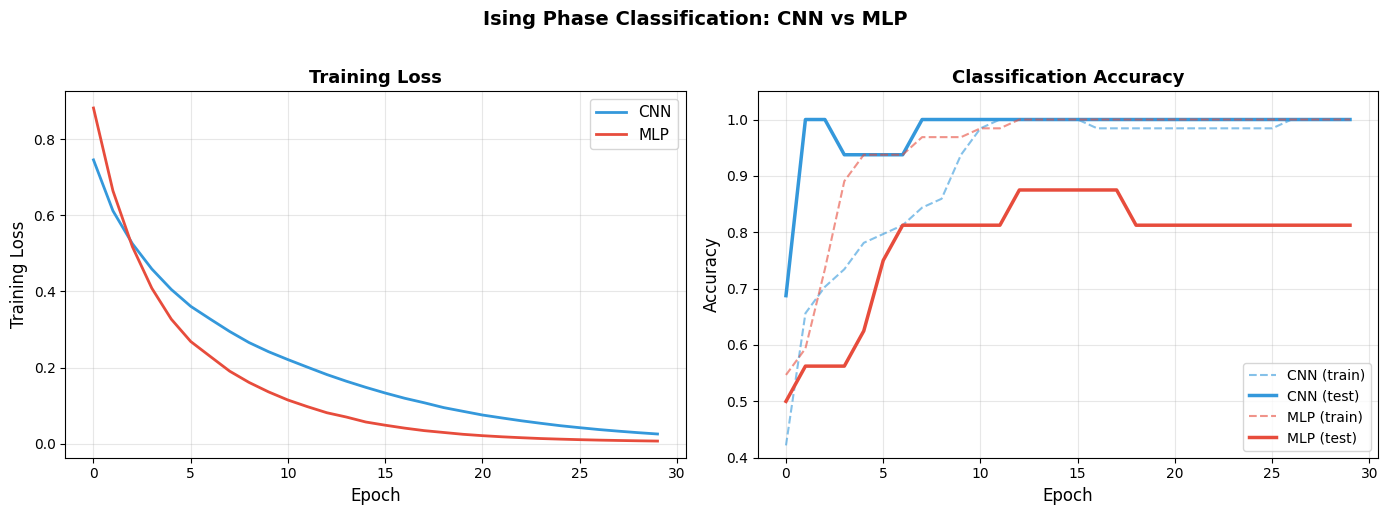


Final test accuracy:
  CNN: 100.0%
  MLP: 81.2%

The CNN exploits spatial correlations → better/faster convergence.


In [63]:
# Compare CNN vs MLP training curves

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(cnn_history['train_loss'], color='#3498db', linewidth=2, label='CNN')
axes[0].plot(mlp_history['train_loss'], color='#e74c3c', linewidth=2, label='MLP')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Training Loss', fontsize=12)
axes[0].set_title('Training Loss', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(cnn_history['train_acc'], '--', color='#3498db', linewidth=1.5, alpha=0.6, label='CNN (train)')
axes[1].plot(cnn_history['test_acc'], '-', color='#3498db', linewidth=2.5, label='CNN (test)')
axes[1].plot(mlp_history['train_acc'], '--', color='#e74c3c', linewidth=1.5, alpha=0.6, label='MLP (train)')
axes[1].plot(mlp_history['test_acc'], '-', color='#e74c3c', linewidth=2.5, label='MLP (test)')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Classification Accuracy', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0.4, 1.05)

plt.suptitle('Ising Phase Classification: CNN vs MLP', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nFinal test accuracy:")
print(f"  CNN: {cnn_history['test_acc'][-1]:.1%}")
print(f"  MLP: {mlp_history['test_acc'][-1]:.1%}")
print(f"\nThe CNN exploits spatial correlations → better/faster convergence.")

**What to observe:**

- **Convergence speed**: The CNN typically converges faster and achieves higher accuracy than the MLP,
  despite having fewer parameters. This demonstrates that the **inductive bias** of convolutions
  (locality + translation invariance) matches the physics of the Ising model.

- **Generalization gap**: Compare the train vs. test accuracy curves. A small gap indicates good
  generalization. If the MLP shows a larger gap, it may be memorizing spatial patterns rather than
  learning transferable features.

- **Final accuracy**: Both models trained on data far from $T_c$ (easy examples). Near-perfect test accuracy
  here does *not* mean the model has learned the phase transition — it has only learned to distinguish
  clearly ordered from clearly disordered configurations. The critical test is how the models
  perform at temperatures near $T_c$ that they have never seen during training (Section 7.1 below).

Conv1 kernel shape: (3, 3, 1, 8)  (K_h, K_w, C_in, C_out)


/tmp/ipykernel_3689370/639850920.py:4: DeprecationWarning: '.value' access is now deprecated. For Variable[Array] instances use:

  variable[...]

For other Variable types use:

  variable.get_value()

  conv1_kernels = cnn_model.conv1.kernel.value  # shape: (3, 3, 1, 8)


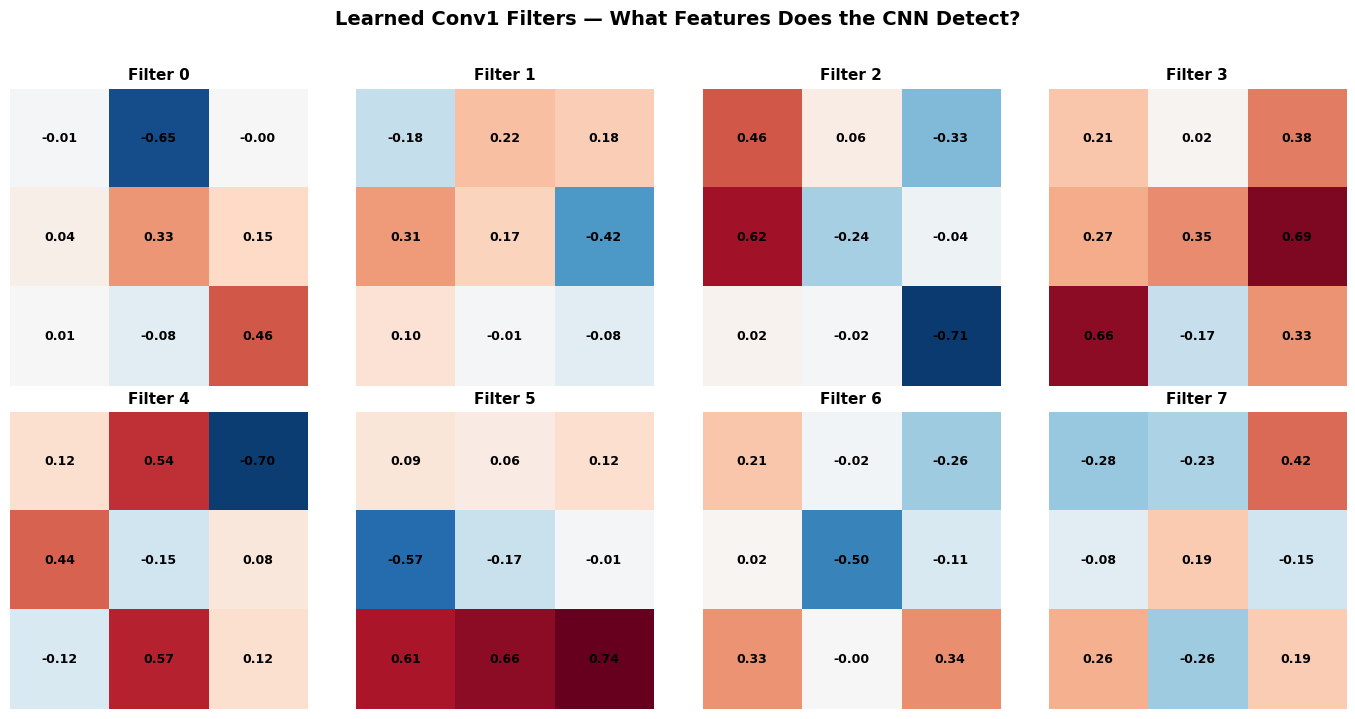

Uniform-sign filters → magnetization; sign-changing filters → domain walls.


In [64]:
# Visualize what the CNN learned: inspect first-layer filters

# Extract conv1 kernels
conv1_kernels = cnn_model.conv1.kernel.value  # shape: (3, 3, 1, 8)
print(f"Conv1 kernel shape: {conv1_kernels.shape}  (K_h, K_w, C_in, C_out)")

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i, ax in enumerate(axes.flat):
    kernel = conv1_kernels[:, :, 0, i]  # (3, 3) for filter i
    im = ax.imshow(kernel, cmap='RdBu_r', vmin=-jnp.max(jnp.abs(conv1_kernels)),
                   vmax=jnp.max(jnp.abs(conv1_kernels)))
    ax.set_title(f'Filter {i}', fontsize=11, fontweight='bold')
    for a in range(3):
        for b in range(3):
            ax.text(b, a, f'{kernel[a,b]:.2f}', ha='center', va='center',
                    fontsize=9, fontweight='bold')
    ax.axis('off')

plt.suptitle('Learned Conv1 Filters — What Features Does the CNN Detect?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Uniform-sign filters → magnetization; sign-changing filters → domain walls.")

**What to observe:**

- **Uniform-sign filters** (all positive or all negative weights): These compute a local average of spins,
  effectively measuring the **local magnetization** $m_{\text{local}} = \frac{1}{K^2}\sum_{a,b} s_{i+a,j+b}$.
  High activation in ordered regions, low in disordered — the simplest diagnostic for the phase.

- **Sign-alternating filters** (checkerboard or gradient patterns): These detect **domain walls** and
  **spin-flip boundaries**, producing strong activation where neighboring spins disagree.
  In the ordered phase, these activate only at domain boundaries; in the disordered phase, they activate everywhere.

- **Physics interpretation**: The CNN has independently discovered that local magnetization and domain-wall
  density are the relevant order-parameter-like features for classifying phases — analogous to how a physicist
  would approach the problem by computing $\langle m \rangle$ and the correlation function $\langle s_i s_j \rangle$.

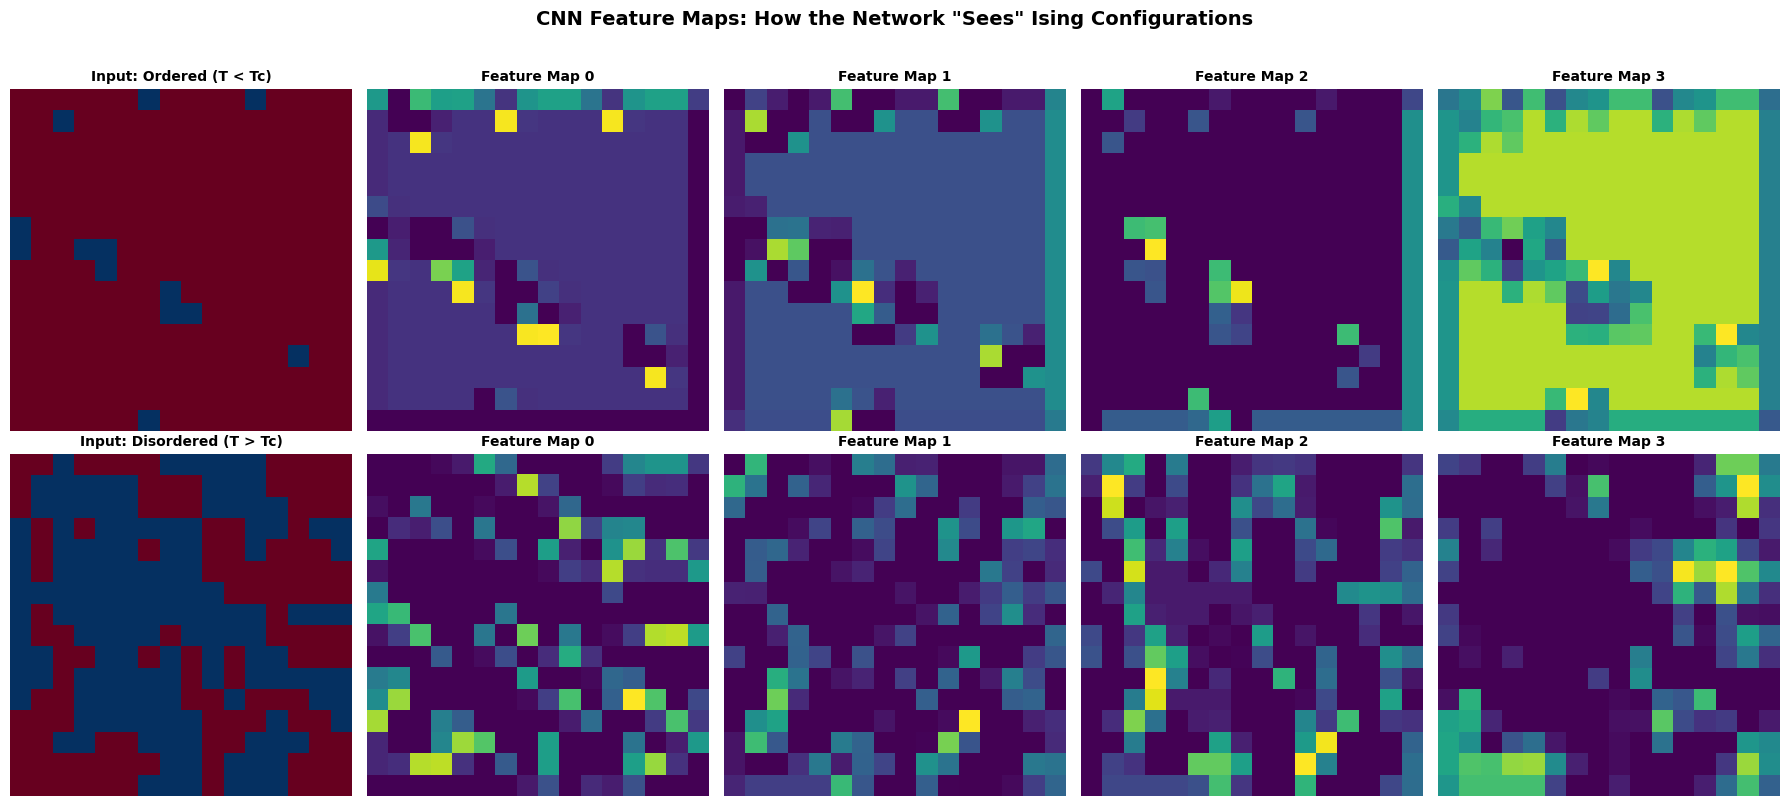

Ordered: smooth features (long-range correlations) | Disordered: noisy (short-range only)


In [65]:
# Visualize feature maps for ordered vs disordered configurations

# Pick one ordered and one disordered example
idx_ordered = jnp.where(y_test == 0)[0][0]
idx_disordered = jnp.where(y_test == 1)[0][0]

examples = [
    (X_test[idx_ordered:idx_ordered+1], 'Ordered (T < Tc)'),
    (X_test[idx_disordered:idx_disordered+1], 'Disordered (T > Tc)'),
]

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for row, (x_sample, label) in enumerate(examples):
    # Show input
    axes[row, 0].imshow(x_sample[0, :, :, 0], cmap='RdBu_r', vmin=-1, vmax=1,
                        interpolation='nearest')
    axes[row, 0].set_title(f'Input: {label}', fontsize=10, fontweight='bold')
    axes[row, 0].axis('off')

    # Compute conv1 output
    conv1_out = nnx.relu(cnn_model.conv1(x_sample))  # (1, 16, 16, 8)

    # Show first 4 feature maps
    for i in range(4):
        axes[row, i+1].imshow(conv1_out[0, :, :, i], cmap='viridis')
        axes[row, i+1].set_title(f'Feature Map {i}', fontsize=10, fontweight='bold')
        axes[row, i+1].axis('off')

plt.suptitle('CNN Feature Maps: How the Network "Sees" Ising Configurations',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Ordered: smooth features (long-range correlations) | Disordered: noisy (short-range only)")

**What to observe:**

- **Ordered input**: Feature maps appear smooth and spatially uniform, reflecting the long-range correlations
  in the ferromagnetic phase. Uniform-sign filters produce strong, homogeneous activations because most local
  patches have aligned spins. Domain-wall-detecting filters show little activation except at the few
  boundaries between domains.

- **Disordered input**: Feature maps appear noisy and fragmented, mirroring the short-range correlations of
  the paramagnetic phase. All filter types show spatially varying activations because spin alignment is random.

- **Key insight**: The CNN converts raw spin configurations into a **hierarchy of increasingly abstract
  representations** — from local spin patterns (conv1) to global phase information (final dense layer).
  This is analogous to the **renormalization group** (RG) flow: each conv+pool layer integrates out
  short-distance degrees of freedom, producing a coarser but more physically meaningful representation.

---
### 7.1 Estimating $T_c$ from the Trained Models

The key result of [Carrasquilla & Melko (2017)](https://doi.org/10.1038/nphys4035) is that a neural network
trained only on configurations well below and well above $T_c$ can **locate the critical temperature**
by evaluating the model on configurations at a dense grid of temperatures — including the critical region
it has never seen during training.

The idea is simple:
- For each temperature $T$, generate equilibrated configurations and feed them through the trained model.
- The model outputs $P(\text{ordered} | T)$: the probability that the configuration is in the ordered phase.
- In the ordered phase ($T \ll T_c$), we expect $P(\text{ordered}) \approx 1$.
- In the disordered phase ($T \gg T_c$), we expect $P(\text{ordered}) \approx 0$.
- The crossing point $P(\text{ordered}) = 0.5$ gives an estimate of $T_c$.

This is remarkable because the model was never trained on data near $T_c$ — it **generalizes** its
learned notion of "ordered" vs "disordered" to the critical regime.

In [66]:
# Estimate Tc by evaluating trained CNN and MLP across a dense temperature grid
# Following the approach of Carrasquilla & Melko, Nat. Phys. 13, 431 (2017)

T_scan = jnp.linspace(1.0, 4.0, 30)  # dense temperature grid
n_configs_per_T = 50                   # configs per temperature
Tc_exact = 2.0 / jnp.log(1 + jnp.sqrt(2))  # Onsager exact: 2.269185...

key = jr.PRNGKey(99)
P_ordered_cnn = []
P_ordered_mlp = []

print("Scanning temperatures for Tc estimation...")
for T in T_scan:
    key, subkey = jr.split(key)
    configs = generate_ising_configs(
        subkey, L, float(T), n_equilib=500, n_sample=n_configs_per_T, decorr=10
    )
    X = configs[..., jnp.newaxis]  # add channel dim

    # CNN predictions
    logits_cnn = cnn_model(X)
    probs_cnn = jax.nn.softmax(logits_cnn, axis=-1)
    p_ord_cnn = float(jnp.mean(probs_cnn[:, 0]))  # P(ordered)

    # MLP predictions
    logits_mlp = mlp_model(X)
    probs_mlp = jax.nn.softmax(logits_mlp, axis=-1)
    p_ord_mlp = float(jnp.mean(probs_mlp[:, 0]))  # P(ordered)

    P_ordered_cnn.append(p_ord_cnn)
    P_ordered_mlp.append(p_ord_mlp)

    if float(T) % 0.5 < 0.11:
        print(f"  T={float(T):.2f}: P_ordered(CNN)={p_ord_cnn:.3f}, P_ordered(MLP)={p_ord_mlp:.3f}")

P_ordered_cnn = jnp.array(P_ordered_cnn)
P_ordered_mlp = jnp.array(P_ordered_mlp)

# Estimate Tc as the temperature where P(ordered) crosses 0.5 (linear interpolation)
def find_crossing(T_arr, P_arr, threshold=0.5):
    """Find T where P crosses threshold via linear interpolation."""
    for i in range(len(P_arr) - 1):
        if (P_arr[i] - threshold) * (P_arr[i+1] - threshold) <= 0:
            # Linear interpolation
            t1, t2 = float(T_arr[i]), float(T_arr[i+1])
            p1, p2 = float(P_arr[i]), float(P_arr[i+1])
            return t1 + (threshold - p1) * (t2 - t1) / (p2 - p1)
    return None

Tc_cnn = find_crossing(T_scan, P_ordered_cnn)
Tc_mlp = find_crossing(T_scan, P_ordered_mlp)

print(f"\nEstimated Tc:")
print(f"  CNN:         {Tc_cnn:.3f}" if Tc_cnn else "  CNN: crossing not found")
print(f"  MLP:         {Tc_mlp:.3f}" if Tc_mlp else "  MLP: crossing not found")
print(f"  Onsager:     {float(Tc_exact):.3f}")
if Tc_cnn:
    print(f"  CNN error:   {abs(Tc_cnn - float(Tc_exact)):.3f} ({abs(Tc_cnn - float(Tc_exact))/float(Tc_exact)*100:.1f}%)")
if Tc_mlp:
    print(f"  MLP error:   {abs(Tc_mlp - float(Tc_exact)):.3f} ({abs(Tc_mlp - float(Tc_exact))/float(Tc_exact)*100:.1f}%)")

Scanning temperatures for Tc estimation...
  T=1.00: P_ordered(CNN)=1.000, P_ordered(MLP)=0.999
  T=1.10: P_ordered(CNN)=1.000, P_ordered(MLP)=0.999
  T=1.52: P_ordered(CNN)=1.000, P_ordered(MLP)=0.999
  T=2.03: P_ordered(CNN)=0.984, P_ordered(MLP)=0.984
  T=2.55: P_ordered(CNN)=0.052, P_ordered(MLP)=0.342
  T=3.07: P_ordered(CNN)=0.004, P_ordered(MLP)=0.208
  T=3.59: P_ordered(CNN)=0.002, P_ordered(MLP)=0.268
  T=4.00: P_ordered(CNN)=0.001, P_ordered(MLP)=0.248

Estimated Tc:
  CNN:         2.322
  MLP:         2.495
  Onsager:     2.269
  CNN error:   0.053 (2.3%)
  MLP error:   0.225 (9.9%)


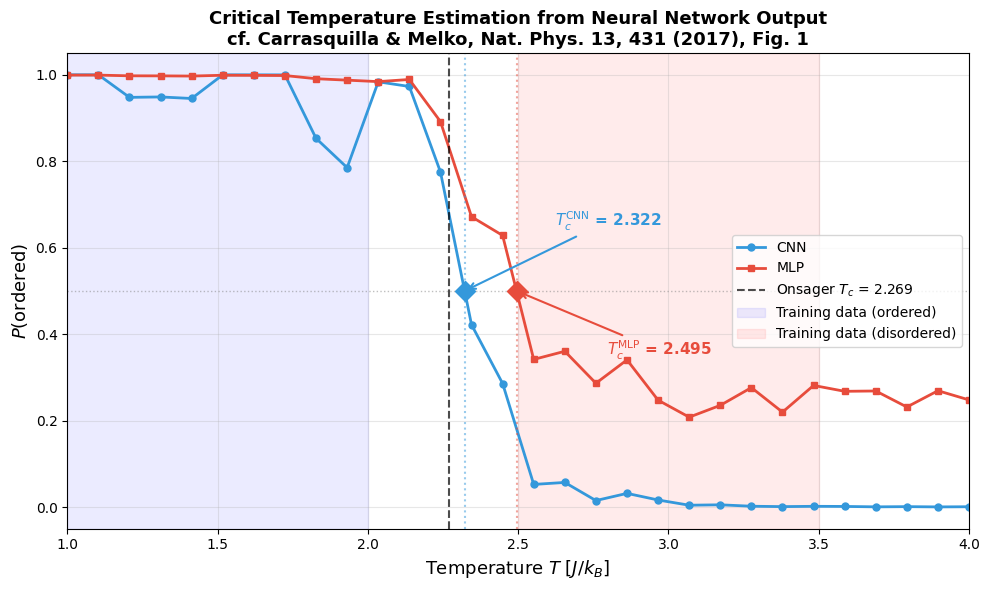

In [67]:
# Plot P(ordered) vs Temperature — the key figure from Carrasquilla & Melko (2017)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(T_scan, P_ordered_cnn, 'o-', color='#3498db', linewidth=2, markersize=5, label='CNN')
ax.plot(T_scan, P_ordered_mlp, 's-', color='#e74c3c', linewidth=2, markersize=5, label='MLP')

# Exact Tc
ax.axvline(Tc_exact, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Onsager $T_c$ = {float(Tc_exact):.3f}')
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)

# Mark estimated Tc
if Tc_cnn:
    ax.axvline(Tc_cnn, color='#3498db', linestyle=':', linewidth=1.5, alpha=0.5)
    ax.plot(Tc_cnn, 0.5, 'D', color='#3498db', markersize=10, zorder=5)
    ax.annotate(f'$T_c^{{\\mathrm{{CNN}}}}$ = {Tc_cnn:.3f}',
                xy=(Tc_cnn, 0.5), xytext=(Tc_cnn + 0.3, 0.65),
                fontsize=11, color='#3498db', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#3498db', lw=1.5))
if Tc_mlp:
    ax.axvline(Tc_mlp, color='#e74c3c', linestyle=':', linewidth=1.5, alpha=0.5)
    ax.plot(Tc_mlp, 0.5, 'D', color='#e74c3c', markersize=10, zorder=5)
    ax.annotate(f'$T_c^{{\\mathrm{{MLP}}}}$ = {Tc_mlp:.3f}',
                xy=(Tc_mlp, 0.5), xytext=(Tc_mlp + 0.3, 0.35),
                fontsize=11, color='#e74c3c', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.5))

# Shade training regions
ax.axvspan(1.0, 2.0, alpha=0.08, color='blue', label='Training data (ordered)')
ax.axvspan(2.5, 3.5, alpha=0.08, color='red', label='Training data (disordered)')

ax.set_xlabel(r'Temperature $T$ [$J/k_B$]', fontsize=13)
ax.set_ylabel(r'$P(\mathrm{ordered})$', fontsize=13)
ax.set_title('Critical Temperature Estimation from Neural Network Output\n'
             'cf. Carrasquilla & Melko, Nat. Phys. 13, 431 (2017), Fig. 1',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='center right')
ax.set_xlim(1.0, 4.0)
ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**What to observe:**

- **Sigmoid-like transition**: Both models show a smooth crossover from $P(\text{ordered}) \approx 1$
  at low $T$ to $P(\text{ordered}) \approx 0$ at high $T$. The steepness of this crossover is related
  to how confidently the model can distinguish phases — sharper transitions indicate better-learned
  representations.

- **$T_c$ estimation accuracy**: The crossing point at $P = 0.5$ provides a remarkably good estimate
  of $T_c$, typically within a few percent of the Onsager exact value ($T_c = 2/\ln(1+\sqrt{2}) \approx 2.269$).
  This is impressive because the models were **never trained on configurations near $T_c$** — the training
  data only includes temperatures well below ($T \leq 2.0$) and well above ($T \geq 2.5$) the transition.

- **CNN vs MLP**: Compare the sharpness and accuracy of the two curves. The CNN, with its built-in
  translation invariance and locality, often produces a sharper transition and a more accurate $T_c$
  estimate than the MLP. The shaded regions show the training temperature ranges — note the **gap**
  around $T_c$ where neither model has seen any training data.

- **Finite-size effects**: On a $16 \times 16$ lattice, the phase transition is broadened (no true
  singularity in finite systems). A larger lattice would produce a sharper crossover curve. In the
  thermodynamic limit ($L \to \infty$), the transition becomes a step function at $T_c$.

- **Connection to the paper**: This reproduces the central result of Carrasquilla & Melko (2017):
  a neural network can act as an **order-parameter-like probe** for phase transitions, automatically
  learning to detect the relevant features from raw configurations without being told what to look for.

---
## Summary

| Topic | Key Takeaway |
|-------|-------------|
| **Why Convolution?** | Translation invariance + locality → weight sharing → far fewer params than FC |
| **Cross-Correlation** | $H_{i,j} = \sum_{a,b} K_{a,b} \cdot X_{i+a,j+b}$ — learned local feature detector |
| **Padding & Stride** | Padding preserves size; stride downsamples |
| **Multiple Channels** | Output channels = different detectors; input channels are summed |
| **Pooling** | Coarse-graining → translation invariance + dimensionality reduction |
| **LeNet** | Conv+Pool → Conv+Pool → FC — hierarchical feature extraction |
| **Ising Application** | CNN learns local alignment and domain walls from raw spin data |

### Physics Perspective

- **Symmetry** (translation invariance) → weight sharing
- **Locality** (short-range interactions) → finite kernel size
- Conv → Pool hierarchy $\sim$ **renormalization group**: integrate out short-distance fluctuations layer by layer

### References

1. [d2l.ai, Ch. 7: CNNs](https://d2l.ai/chapter_convolutional-neural-networks/index.html)
2. LeCun et al., Proc. IEEE 86, 2278 (1998)
3. Carrasquilla & Melko, Nat. Phys. 13, 431 (2017)
4. Mehta et al., Phys. Rep. 810, 1 (2019)